In [1]:
!pip -q install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 19.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import lightning as L

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Keeping the seed fixed so I get the same results when I rerun this notebook
L.seed_everything(21)
np.random.seed(21)
torch.manual_seed(21)

INFO: Seed set to 21
INFO:lightning.fabric.utilities.seed:Seed set to 21


In [3]:
# Creating a nonlinear regression dataset with 3 input variables
def create_regression_data(sample_count=6200, noise_level=0.07, seed_value=21):
    rng = np.random.default_rng(seed_value)

    input_1 = rng.uniform(-2.8, 2.8, size=(sample_count, 1))
    input_2 = rng.uniform(-2.6, 2.6, size=(sample_count, 1))
    input_3 = rng.uniform(-2.4, 2.4, size=(sample_count, 1))

    # Slightly changing the target equation so this version is not exactly the same
    target = (
        np.sin(1.12 * input_1)
        + 0.44 * (input_2 ** 2)
        - 0.58 * np.cos(1.7 * input_3)
        + 0.23 * (input_1 * input_2)
        - 0.17 * (input_2 * input_3)
        + 0.09 * (input_1 ** 2)
    )

    # Adding a bit of noise so the data is not too perfect
    target = target + rng.normal(0.0, noise_level, size=target.shape)

    features = np.concatenate([input_1, input_2, input_3], axis=1).astype(np.float32)
    target = target.astype(np.float32)

    return features, target

X_data, y_data = create_regression_data()

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([4960, 3])
y_train shape: torch.Size([4960, 1])
X_test shape: torch.Size([1240, 3])
y_test shape: torch.Size([1240, 1])


In [4]:
# Creating dataloaders so Lightning can handle training in batches
batch_size = 256

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Building the model using PyTorch Lightning
class LightningRegressionModel(L.LightningModule):
    def __init__(self, input_dim=3, hidden_dim_1=64, hidden_dim_2=32, learning_rate=0.008):
        super().__init__()

        self.save_hyperparameters()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.Tanh(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.Tanh(),
            nn.Linear(hidden_dim_2, 1)
        )

        self.loss_function = nn.MSELoss()

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        features, targets = batch
        predictions = self(features)
        loss = self.loss_function(predictions, targets)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        features, targets = batch
        predictions = self(features)
        loss = self.loss_function(predictions, targets)

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

model = LightningRegressionModel()
print(model)

LightningRegressionModel(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (loss_function): MSELoss()
)


In [6]:
# Training with Lightning makes the training loop much shorter
trainer = L.Trainer(
    max_epochs=120,
    enable_checkpointing=False,
    logger=False,
    enable_model_summary=True
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=test_loader)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network       │ Sequential │  2.4 K │ train │     0 │
│ 1 │ loss_function │ MSELoss    │      0 │ train │     0 │
└───┴───────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=120` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=120` reached.


In [7]:
# After training, checking predictions on the test set
model.eval()

with torch.no_grad():
    final_test_predictions = model(X_test)

final_mse = torch.mean((final_test_predictions - y_test) ** 2).item()
final_mae = torch.mean(torch.abs(final_test_predictions - y_test)).item()

print("Final Test MSE:", round(final_mse, 6))
print("Final Test MAE:", round(final_mae, 6))

Final Test MSE: 0.005928
Final Test MAE: 0.061994


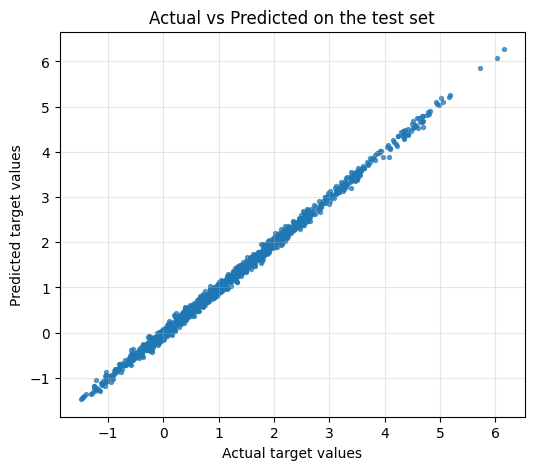

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze().numpy(), final_test_predictions.squeeze().numpy(), s=8, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("Actual vs Predicted on the test set")
plt.grid(alpha=0.3)
plt.show()

### Final Observation
In this notebook, I implemented the same nonlinear regression problem using PyTorch Lightning. Compared to regular PyTorch, Lightning makes the training code much cleaner because a lot of the boilerplate gets handled inside the framework, while the model still learns the overall pattern in the data well.